In [ ]:
# IMPORTS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, LSTM, Dropout, TimeDistributed, Input, RepeatVector
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.models import load_model


pd.options.display.max_rows = 99999
pd.options.display.max_colwidth = 99999
print(tf.config.list_physical_devices('GPU'))

[]


In [ ]:
# ULTILITY FUNCTION
def create_sequence(mtx, timestep:int):
  x = []
  y = []
  window = timestep + 1

  for i in range(mtx.shape[0] - window + 1):
    sample = mtx[i: i+window]
    x.append(sample[:-1])
    y.append([sample[-1][-1]])

  return np.array(x), np.array(y)

In [ ]:
tetouan = pd.read_csv("final_tetouan.csv")
tetouan['DateTime'] = pd.to_datetime(tetouan["DateTime"], format='mixed')
tetouan = tetouan.set_index('DateTime')

display(tetouan.head())
display(tetouan.info())

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption,Hours,Weekdays,Months,Days of Year
DateTime,,,,,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,0,6,1,1
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,0,6,1,1
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,0,6,1,1
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,0,6,1,1
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,0,6,1,1


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52416 entries, 2017-01-01 00:00:00 to 2017-12-30 23:50:00
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Temperature                52416 non-null  float64
 1   Humidity                   52416 non-null  float64
 2   Wind Speed                 52416 non-null  float64
 3   general diffuse flows      52416 non-null  float64
 4   diffuse flows              52416 non-null  float64
 5   Zone 1 Power Consumption   52416 non-null  float64
 6   Zone 2  Power Consumption  52416 non-null  float64
 7   Zone 3  Power Consumption  52416 non-null  float64
 8   Hours                      52416 non-null  int64  
 9   Weekdays                   52416 non-null  int64  
 10  Months                     52416 non-null  int64  
 11  Days of Year               52416 non-null  int64  
dtypes: float64(8), int64(4)
memory usage: 5.2 MB


None

# **KEY IDEA**  
- One-step forecast.
- Looking at current + multiple past timesteps to predict the next one future step.
- LSTM is powerful in handling long and short term information.
- Select 3 highest correlated columns.

# **IMPLEMENTATION**
### Input shape is 3D tensor: [samples, timesteps, features].
- samples = `original_array.shape[0] - timesteps + 1`.
- timesteps = defined by user.
- features = 4 `[Hour, Temperature, Days of Year, Zone 2 Power Consumption]`.
### Output shape is 2D array (1 x 1):
- Row is number of predicted step (this scenario is one step).
- Column is only one target feature `Zone 2 Power Consumption`.
- Value is the predicted power consumption.
### In other word:
`[Hour, Temperature, Days of Year, Zone 2 Power Consumption]` **==[LSTM MODEL]==>** `[Zone 2 Power Consumption]`.
- Inputs are known current / past values.
- Input is updated in each timestep (real-time).
- To prevent data leak and improve forecast performance.

In [ ]:
# Select 3 highest correlated features
z2 = tetouan[['Hours', 'Temperature', 'Days of Year', 'Zone 2  Power Consumption']].copy()

timesteps = 36

In [ ]:
# First split
train_size = int(tetouan.shape[0]*0.75)
test_size = train_size - timesteps

train_set, test_set = z2[:train_size], z2[test_size:]

display(test_set.shape)

(13140, 4)

In [ ]:
# Fit MinMaxScaler
input_scaler = MinMaxScaler(feature_range=(-1,1)).fit(train_set.values)
output_scaler = MinMaxScaler(feature_range=(-1,1)).fit(train_set['Zone 2  Power Consumption'].values.reshape(-1,1))

scaled_train = input_scaler.transform(train_set.values)
scaled_test = input_scaler.transform(test_set.values)

print(scaled_test)

[[ 0.56521739  0.06427658  1.          0.01453841]
 [ 0.56521739  0.0582923   1.          0.13880818]
 [ 0.56521739  0.05557218  1.          0.23428057]
 ...
 [ 1.         -0.80126758  1.66911765  0.15898222]
 [ 1.         -0.80899274  1.66911765  0.11839432]
 [ 1.         -0.81867639  1.66911765  0.07423264]]


In [ ]:
# Tensorization

X_train, y_train = create_sequence(scaled_train, timesteps)
X_test, y_test = create_sequence(scaled_test, timesteps)

print(X_train.shape)
print(y_train.shape)

(39276, 36, 4)
(39276, 1)


In [ ]:
tf.keras.backend.clear_session()

lstm_z1 = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64, activation='tanh', kernel_initializer='glorot_normal', seed=26, return_sequences=False, dropout=0.2),
    Dense(1, activation='tanh')
])

In [ ]:
lstm_z1.compile(optimizer=Adam(learning_rate=0.001, ema_momentum=0.9), loss='mae')
lstm_z1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,729 (69.25 KB)

 Trainable params: 17,729 (69.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
call_back = EarlyStopping(patience=5, restore_best_weights=True, start_from_epoch=10)

lstm_z1_fit = lstm_z1.fit(
    x=X_train, y=y_train,
    batch_size=256,
    validation_split=0.1,
    verbose=1,
    callbacks=[call_back],
    shuffle = False,
    epochs=50
)

lstm_z1.save("multi_lstm_z2.keras")

Epoch 1/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - loss: 0.1087 - val_loss: 0.0887
Epoch 2/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - loss: 0.0878 - val_loss: 0.0787
Epoch 3/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - loss: 0.0749 - val_loss: 0.0664
Epoch 4/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - loss: 0.0711 - val_loss: 0.0606
Epoch 5/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 20s 77ms/step - loss: 0.0690 - val_loss: 0.0644
Epoch 6/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - loss: 0.0661 - val_loss: 0.0539
Epoch 7/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - loss: 0.0649 - val_loss: 0.0555
Epoch 8/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - loss: 0.0627 - val_loss: 0.0609
Epoch 9/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - loss: 0.0634 - val_loss: 0.0440
Epoch 10/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - loss: 0.0612 - val_loss: 0.0504
Epoch 11/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - loss: 0.0594 - val_loss: 0.0482
Epoch 12/50
139/139 ━━━━━━━━━━

In [ ]:
model_z2 = load_model("multi_lstm_z2.keras")
model_z2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,189 (207.77 KB)

 Trainable params: 17,729 (69.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 35,460 (138.52 KB)

In [ ]:
pred = model_z2.predict(X_test)

print(pred.shape)

410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
(13104, 1)


In [ ]:
pred_org = output_scaler.inverse_transform(pred).flatten()
y_test_org = output_scaler.inverse_transform(y_test).flatten()

lstm_z2_rmse = root_mean_squared_error(pred_org, y_test_org)
lstm_z2_mae = mean_absolute_error(pred_org, y_test_org)

print(lstm_z2_rmse)
print(lstm_z2_mae)

1659.6403867638242
1291.4181112556516


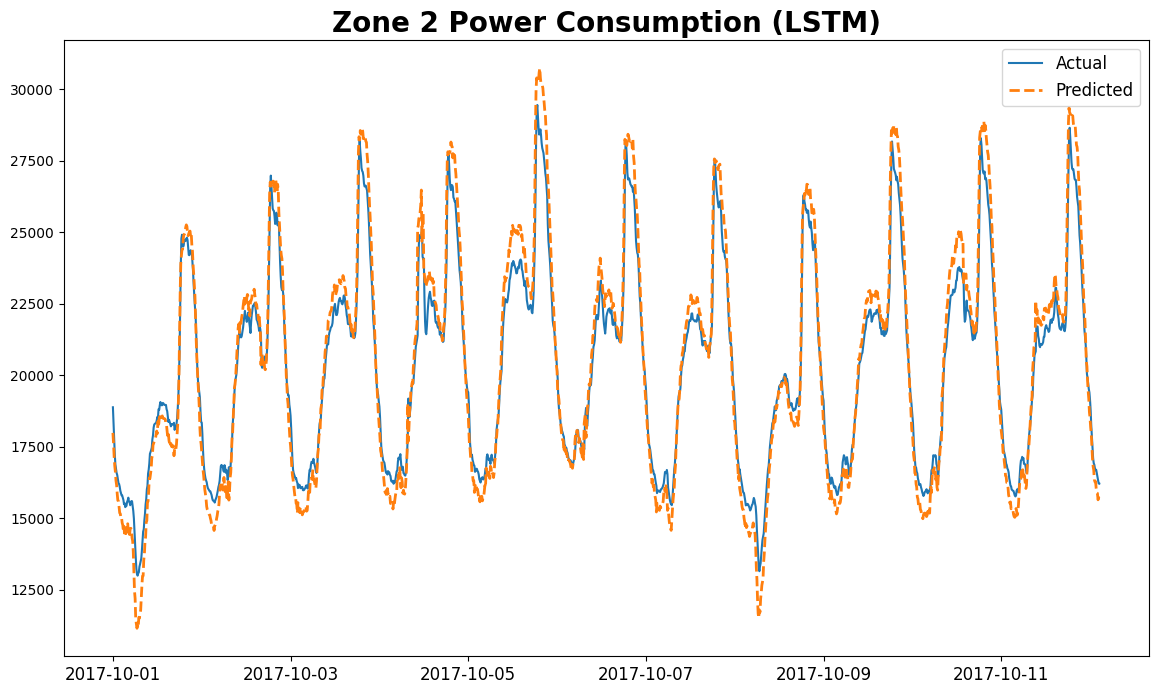

In [ ]:
index = test_set['Zone 2  Power Consumption'][timesteps:].index

plt.figure(figsize=(14,8))
plt.plot(index[:1600], pred_org[:1600], label="Actual")
plt.plot(index[:1600], y_test_org[:1600], label="Predicted", lw=2, ls="--")
plt.title("Zone 2 Power Consumption (LSTM)", fontsize=20, fontweight='bold')
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.show()